In [2]:
# 📌 Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Display settings
sns.set_theme(style="whitegrid", font_scale=1.2)


In [3]:
# 📌 Step 2: Load dataset
df = pd.read_csv("../data/netflix_titles.csv")
print(df.shape)
df.head()


(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# 📌 Step 3: Basic cleaning
df = df.drop_duplicates()
df = df.dropna(subset=["type", "country", "release_year", "listed_in", "description"])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7976 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7976 non-null   object
 1   type          7976 non-null   object
 2   title         7976 non-null   object
 3   director      5751 non-null   object
 4   cast          7305 non-null   object
 5   country       7976 non-null   object
 6   date_added    7967 non-null   object
 7   release_year  7976 non-null   int64 
 8   rating        7973 non-null   object
 9   duration      7973 non-null   object
 10  listed_in     7976 non-null   object
 11  description   7976 non-null   object
dtypes: int64(1), object(11)
memory usage: 810.1+ KB


C:\Users\kaush\AppData\Local\Temp\ipykernel_14740\2283853043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=df, palette="Set2")


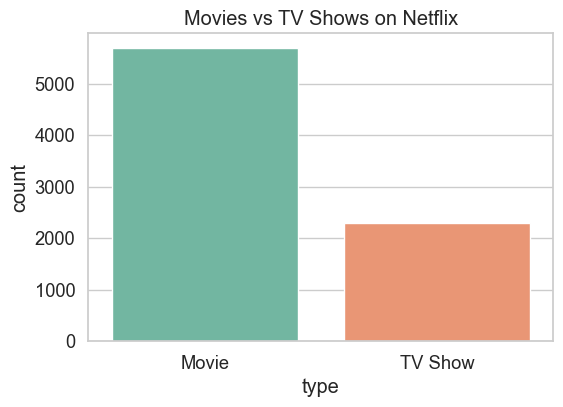

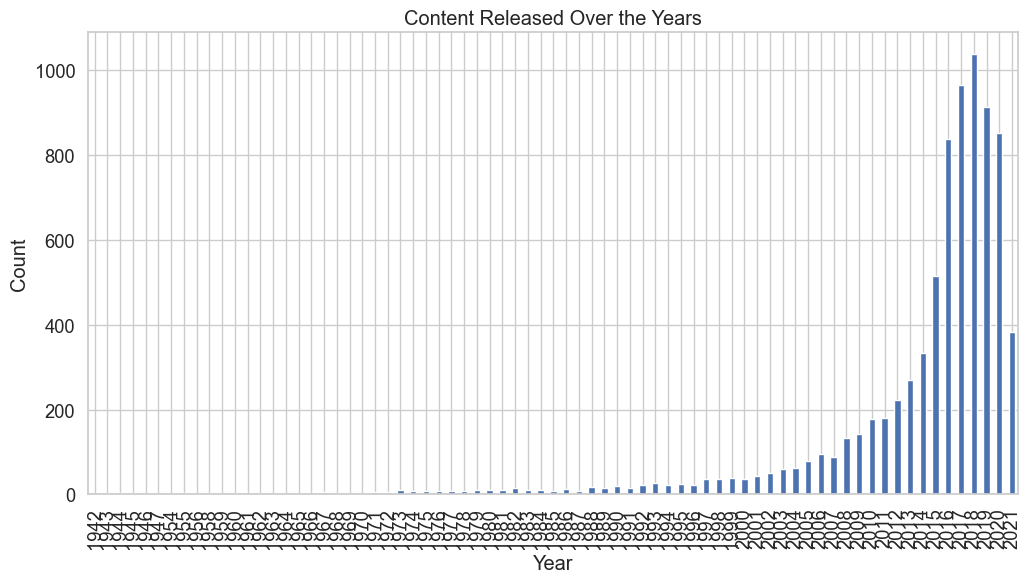

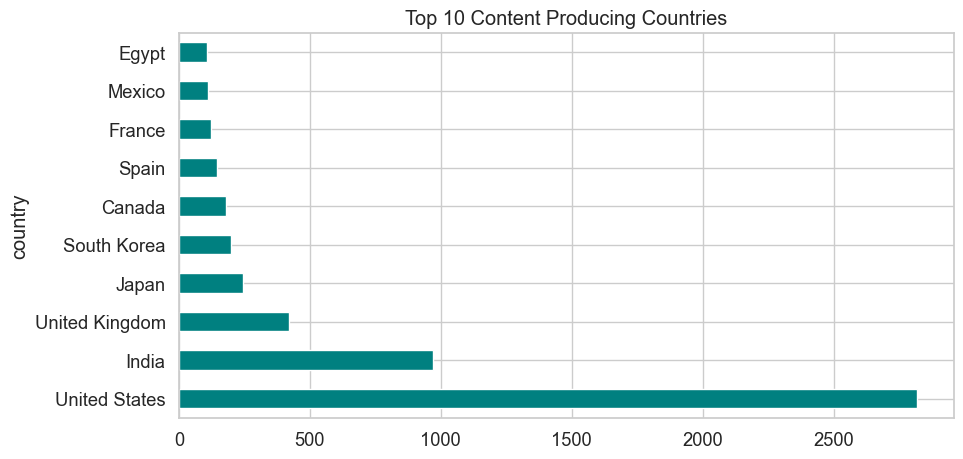

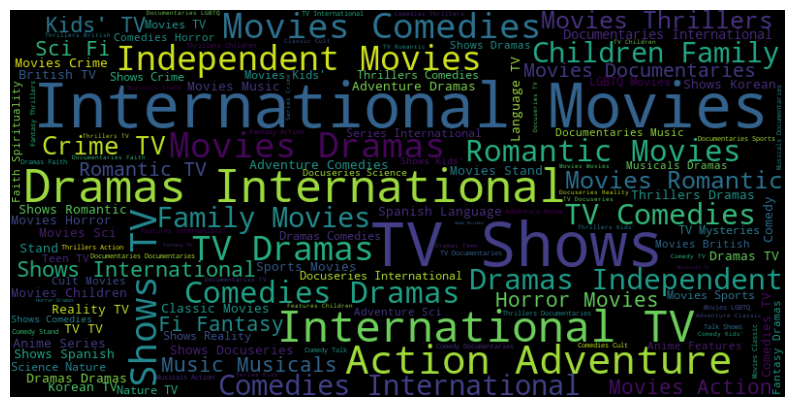

In [5]:
# 📌 Step 4: Exploratory Data Analysis

# Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df, palette="Set2")
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("../outputs/plots/movies_vs_tvshows.png")
plt.show()

# Trend over years
plt.figure(figsize=(12,6))
df["release_year"].value_counts().sort_index().plot(kind="bar")
plt.title("Content Released Over the Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.savefig("../outputs/plots/trend_years.png")
plt.show()

# Top 10 countries
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="barh", color="teal")
plt.title("Top 10 Content Producing Countries")
plt.savefig("../outputs/plots/top_countries.png")
plt.show()

# Wordcloud of genres
text = " ".join(df["listed_in"])
wc = WordCloud(width=800, height=400, background_color="black").generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig("../outputs/plots/wordcloud_genres.png")
plt.show()


In [6]:
# 📌 Step 5: Simple ML Model
# Predict if title is Movie or TV Show

df_ml = df[["type", "release_year", "duration"]].dropna()
df_ml["duration_num"] = df_ml["duration"].str.extract("(\d+)").astype(float).fillna(0)

X = df_ml[["release_year", "duration_num"]]
y = (df_ml["type"] == "Movie").astype(int)  # Movie=1, TV=0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9981191222570532
